Ali İhsan Cengiz 22120205021

## Import

In [105]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim

## A.1 Representing kets and bras

### Constant variable

In [106]:
inv_sqrt = 1 / np.sqrt(2)

### |0> state

In [107]:
ket_0 = np.array([[1], [0]], dtype=complex)

### |1> state

In [108]:
ket_1 = np.array([[0], [1]], dtype=complex)

### |+> state

In [109]:
ket_pozitif = inv_sqrt * (ket_0 + ket_1)

### |-> state

In [110]:
ket_negatif = inv_sqrt * (ket_0 - ket_1)

### |+i> state

In [111]:
ket_pozitif_i = inv_sqrt * (ket_0 + 1j * ket_1) # 1j Python'da i'e eşit

### |-i> state

In [112]:
ket_negatif_i = inv_sqrt * (ket_0 - 1j * ket_1)

### Printing the arrays

In [113]:
states = {
    "|0>": ket_0,
    "|1>": ket_1,
    "|+>": ket_pozitif,
    "|->": ket_negatif,
    "|+i>": ket_pozitif_i,
    "|-i>": ket_negatif_i
}

In [114]:
for name, state in states.items():
    print(f"State {name}:\n{state}\n")

State |0>:
[[1.+0.j]
 [0.+0.j]]

State |1>:
[[0.+0.j]
 [1.+0.j]]

State |+>:
[[0.70710678+0.j]
 [0.70710678+0.j]]

State |->:
[[ 0.70710678+0.j]
 [-0.70710678+0.j]]

State |+i>:
[[0.70710678+0.j        ]
 [0.        +0.70710678j]]

State |-i>:
[[0.70710678+0.j        ]
 [0.        -0.70710678j]]



## A.2 Bras and inner products

In [115]:
def inner(psi, phi):
    # ket -> ∣ψ⟩, bra -> ⟨ψ∣
    # ket'e conjugate transpoz yapınca bra oluşur
    bra_psi = np.conj(psi).T # psi'in conjugate transpozu

    result = bra_psi @ phi # ket-bra matrix çarpımı
    return result[0, 0]

### Test out ⟨0∣1⟩ ⟨+∣+⟩ ⟨+∣−⟩ ⟨0∣+⟩

In [116]:
# rounding for floating arithmetic
print(f"<0|1>: {np.round(inner(ket_0, ket_1), 5)}")
print(f"<+|+>: {np.round(inner(ket_pozitif, ket_pozitif), 5)}")
print(f"<+|->: {np.round(inner(ket_pozitif, ket_negatif), 5)}")
print(f"<0|+>: {np.round(inner(ket_0, ket_pozitif), 5)}")

<0|1>: 0j
<+|+>: (1+0j)
<+|->: 0j
<0|+>: (0.70711+0j)


### Verify the values ⟨+∣+⟩ = 1 and ⟨+∣−⟩ = 0

⟨+∣+⟩ = 1 (normalization), inner product of a state with itself represents total probability. The probability of a state being itself is 100%. All valid quantum states must be normalized so that their self-inner product equals to 1.

⟨+∣−⟩ = 0 (orthogonality), means that ∣+⟩ and ∣−⟩ are completely distinct, mutually exclusive states. If a qubit is measured in x-basis, it will collapse to either ∣+⟩ or ∣−⟩. If it is definitively in the ∣+⟩ state, the probability of finding it in the ∣−⟩ state is exactly zero. ∣+⟩ and ∣−⟩ are opposites on the x-axis.

## A.3 Normalization 

In [117]:
def norm(psi): # norm √(⟨ψ|ψ⟩)
    bra_psi = np.conj(psi).T

    inner_product = bra_psi @ psi

    return np.sqrt(np.real(inner_product[0, 0]))

### Testing Normalization

In [118]:
states = {
    "|0>": ket_0,
    "|1>": ket_1,
    "|+>": ket_pozitif,
    "|->": ket_negatif,
    "|+i>": ket_pozitif_i,
    "|-i>": ket_negatif_i
}

In [119]:
for name, state in states.items():
    state_norm = np.round(norm(state), 5)
    print(f"Norm of {name}: {state_norm}")

Norm of |0>: 1.0
Norm of |1>: 1.0
Norm of |+>: 1.0
Norm of |->: 1.0
Norm of |+i>: 1.0
Norm of |-i>: 1.0


## A.4 Measurement probabilities

In [120]:
def probs(psi):
    
    alpha = psi[0, 0] # first row first character
    beta = psi[1, 0] # second row first character

    p0 = np.abs(alpha)**2
    p1 = np.abs(beta)**2

    return (p0, p1)

Testing the probabilities

In [121]:
for name, state in states.items():
    p0, p1 = probs(state)
    
    # Rounding to 5 decimal places to clean up floating-point errors
    p0_rounded = np.round(p0, 5)
    p1_rounded = np.round(p1, 5)
    total_prob = np.round(p0 + p1, 5)
    
    print(f"State {name}: p(|0⟩) = {p0_rounded}, p(|1⟩) = {p1_rounded} | Sum = {total_prob}")

State |0>: p(|0⟩) = 1.0, p(|1⟩) = 0.0 | Sum = 1.0
State |1>: p(|0⟩) = 0.0, p(|1⟩) = 1.0 | Sum = 1.0
State |+>: p(|0⟩) = 0.5, p(|1⟩) = 0.5 | Sum = 1.0
State |->: p(|0⟩) = 0.5, p(|1⟩) = 0.5 | Sum = 1.0
State |+i>: p(|0⟩) = 0.5, p(|1⟩) = 0.5 | Sum = 1.0
State |-i>: p(|0⟩) = 0.5, p(|1⟩) = 0.5 | Sum = 1.0


## A.5 Pauli matrices

In [122]:
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
I = np.eye(2, dtype=complex)

Printing the matrices

In [123]:
matrices = {
    "X (Bit-Flip)": X,
    "Y (Bit/Phase-Flip)": Y,
    "Z (Phase-Flip)": Z,
    "I (Identity)": I
}

for name, matrix in matrices.items():
    print(f"Matrix {name}:\n{matrix}\n")

Matrix X (Bit-Flip):
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

Matrix Y (Bit/Phase-Flip):
[[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]

Matrix Z (Phase-Flip):
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]

Matrix I (Identity):
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]



## A.6 Eigenvalues and eigenvectors

In [124]:
matrices = {
    "X": X,
    "Y": Y,
    "Z": Z
}

Eigenvalues

In [125]:
eigensystems = {}

for name, matrix in zip(['X', 'Y', 'Z'], [X, Y, Z]):
    eigenvals, eigenvecs = np.linalg.eig(matrix)
    
    eigensystems[name] = {'evals': eigenvals, 'evecs': eigenvecs}
    
    print(f"Pauli {name} Eigenvalues: {np.round(eigenvals, 5)}")

Pauli X Eigenvalues: [ 1.+0.j -1.+0.j]
Pauli Y Eigenvalues: [ 1.+0.j -1.+0.j]
Pauli Z Eigenvalues: [ 1.+0.j -1.+0.j]


Corresponding Eigenvectors (as kets)

In [126]:
for name in ['X', 'Y', 'Z']:
    evecs = eigensystems[name]['evecs']
    
    ket0 = evecs[:, 0].reshape(2, 1) # (apparently) the columns are eigenvectors in numpy, so reshape them into (2, 1) kets
    ket1 = evecs[:, 1].reshape(2, 1)
    
    eigensystems[name]['ket0'] = ket0
    eigensystems[name]['ket1'] = ket1
    
    print(f"\nPauli {name} Eigenvector 0:\n{np.round(ket0, 5)}")
    print(f"Pauli {name} Eigenvector 1:\n{np.round(ket1, 5)}")


Pauli X Eigenvector 0:
[[0.70711-0.j]
 [0.70711+0.j]]
Pauli X Eigenvector 1:
[[ 0.70711+0.j]
 [-0.70711-0.j]]

Pauli Y Eigenvector 0:
[[-0.     -0.70711j]
 [ 0.70711+0.j     ]]
Pauli Y Eigenvector 1:
[[0.70711+0.j     ]
 [0.     -0.70711j]]

Pauli Z Eigenvector 0:
[[1.+0.j]
 [0.+0.j]]
Pauli Z Eigenvector 1:
[[0.+0.j]
 [1.+0.j]]


Verify Orthonormality

In [127]:
for name in ['X', 'Y', 'Z']:
    ket0 = eigensystems[name]['ket0']
    ket1 = eigensystems[name]['ket1']
    
    norm0 = np.round(norm(ket0), 5)
    norm1 = np.round(norm(ket1), 5)
    overlap = np.round(inner(ket0, ket1), 5)
    
    print(f"\nPauli {name}:")
    print(f" - Norm of Eigenvector 0: {norm0} (Expected: 1.0)")
    print(f" - Norm of Eigenvector 1: {norm1} (Expected: 1.0)")
    print(f" - Inner product ⟨v0|v1⟩:  {overlap} (Expected: 0j)")


Pauli X:
 - Norm of Eigenvector 0: 1.0 (Expected: 1.0)
 - Norm of Eigenvector 1: 1.0 (Expected: 1.0)
 - Inner product ⟨v0|v1⟩:  (-0+0j) (Expected: 0j)

Pauli Y:
 - Norm of Eigenvector 0: 1.0 (Expected: 1.0)
 - Norm of Eigenvector 1: 1.0 (Expected: 1.0)
 - Inner product ⟨v0|v1⟩:  -0j (Expected: 0j)

Pauli Z:
 - Norm of Eigenvector 0: 1.0 (Expected: 1.0)
 - Norm of Eigenvector 1: 1.0 (Expected: 1.0)
 - Inner product ⟨v0|v1⟩:  0j (Expected: 0j)


What physical measurement does each Pauli matrix correspond to?

Hermitian matrices like Pauli matrices represent observables. They correspond to measuring of qubit's spin along the three spatial axes of Bloch sphere  

Pauli-Z corresponds to measuring along Z-axis (standard computational basis), state ∣0⟩ or ∣1⟩?  
Pauli-X corresponds to measuring along X-axis (diagonal basis), state ∣+⟩ or ∣−⟩?  
Pauli-Y corresponds to measuring along Y-axis (circular basis), state ∣+i⟩ or ∣−i⟩?  

## A.7 Applying gates

In [128]:
states_to_test = {
    "|0>": ket_0,
    "|1>": ket_1,
    "|+>": ket_pozitif
}

gates = {
    "X": X,
    "Y": Y,
    "Z": Z
}

In [129]:
for state_name, state_vec in states_to_test.items():
    print(f" Applying Gates to {state_name}")
    
    for gate_name, gate_mat in gates.items():
        result = gate_mat @ state_vec
        
        print(f"{gate_name}{state_name} =\n{np.round(result, 5)}\n")

 Applying Gates to |0>
X|0> =
[[0.+0.j]
 [1.+0.j]]

Y|0> =
[[0.+0.j]
 [0.+1.j]]

Z|0> =
[[1.+0.j]
 [0.+0.j]]

 Applying Gates to |1>
X|1> =
[[1.+0.j]
 [0.+0.j]]

Y|1> =
[[0.-1.j]
 [0.+0.j]]

Z|1> =
[[ 0.+0.j]
 [-1.+0.j]]

 Applying Gates to |+>
X|+> =
[[0.70711+0.j]
 [0.70711+0.j]]

Y|+> =
[[0.-0.70711j]
 [0.+0.70711j]]

Z|+> =
[[ 0.70711+0.j]
 [-0.70711+0.j]]



### Results for |0>  
X∣0⟩=∣1⟩: The array becomes [[0], [1]]. This matches the known action of the X gate: it acts as a quantum NOT gate, flipping a 0 to a 1.  

Y∣0⟩=i∣1⟩: The array becomes [[0], [i]]. The Y gate flips the bit (moves it to the ∣1⟩ state) but also applies an imaginary phase of i (a 90-degree phase shift).  

Z∣0⟩=∣0⟩: The array remains [[1], [0]]. The Z gate leaves the ∣0⟩ state completely unchanged.

### Results for |1>
X∣1⟩=∣0⟩: The array becomes [[1], [0]]. The classical NOT gate action works, flipping the 1 back to a 0.

Y∣1⟩=−i∣0⟩: The array becomes [[-i], [0]]. It flips the bit to ∣0⟩ and applies a phase of −i.

Z∣1⟩=−∣1⟩: The array becomes [[0], [-1]]. This is the move of the Z gate. It leaves the probability of measuring 1 the exact same, but flips its sign (adding a phase of −1 or 180∘).

### Results for |+>
X∣+⟩=∣+⟩: The array remains exactly ∣+⟩. Because ∣+⟩ lies perfectly on the X-axis of the Bloch sphere, rotating it around the X-axis does nothing. It is the +1 eigenstate of X.

Y∣+⟩=−i∣−⟩: This array becomes [[-0.707i], [0.707i]], but if you factor out the −i, you get exactly the ∣−⟩ state. (similar to except for i)

Z∣+⟩=∣−⟩: The array becomes [[0.707], [-0.707]]. The Z gate flipped the sign on the bottom element. Since ∣+⟩=1/√2(∣0⟩+∣1⟩), applying Z changes it to 1/√2(∣0⟩−∣1⟩), which is exactly our ∣−⟩ state.

## A.8 Measurement in different bases

|ψ⟩ = (1/√3)|0⟩ + √(2/3)|1⟩

In [130]:
psi = np.array([[1 / np.sqrt(3)], [np.sqrt(2 / 3)]], dtype=complex)

In [131]:
def measure_prob(basis_state, state): # formula: |⟨basis_state|state⟩|²
    amplitude = inner(basis_state, state)

    return np.abs(amplitude)**2

Probabilities for Z basis (∣0⟩ and ∣1⟩)

In [132]:
print("Measurement in Z Basis")
p_z_pozitif = measure_prob(ket_0, psi)
p_z_negatif = measure_prob(ket_1, psi)

print(f"P(+1) or P(|0⟩): {np.round(p_z_pozitif, 5)}")
print(f"P(-1) or P(|1⟩): {np.round(p_z_negatif, 5)}")
print(f"Check Sum: {np.round(p_z_pozitif + p_z_negatif, 5)}")

Measurement in Z Basis
P(+1) or P(|0⟩): 0.33333
P(-1) or P(|1⟩): 0.66667
Check Sum: 1.0


Probabilities of X basis (∣+⟩ and ∣−⟩)

In [133]:
print("Measurement in X Basis")
p_x_pozitif = measure_prob(ket_pozitif, psi)
p_x_negatif = measure_prob(ket_negatif, psi)

print(f"P(+1) or P(|+⟩): {np.round(p_x_pozitif, 5)}")
print(f"P(-1) or P(|-⟩): {np.round(p_x_negatif, 5)}")
print(f"Check Sum: {np.round(p_x_pozitif + p_x_negatif, 5)}")

Measurement in X Basis
P(+1) or P(|+⟩): 0.9714
P(-1) or P(|-⟩): 0.0286
Check Sum: 1.0


Probabilities of Y basis (∣+i⟩ and ∣−i⟩)

In [134]:
print("Measurement in Y Basis")
p_y_pozitif = measure_prob(ket_pozitif_i, psi)
p_y_negatif = measure_prob(ket_negatif_i, psi)

print(f"P(+1) or P(|+i⟩): {np.round(p_y_pozitif, 5)}")
print(f"P(-1) or P(|-i⟩): {np.round(p_y_negatif, 5)}")
print(f"Check Sum: {np.round(p_y_pozitif + p_y_negatif, 5)}")

Measurement in Y Basis
P(+1) or P(|+i⟩): 0.5
P(-1) or P(|-i⟩): 0.5
Check Sum: 1.0


## A.9 Hermitian and unitary checks

In [135]:
matrices = {
    "X": X,
    "Y": Y,
    "Z": Z
}

Each Pauli matrix is Hermitian: M† = M 

In [136]:
for name, matrix in matrices.items():
    matrix_dag = np.conj(matrix).T # conjugate transpose (M†)
    
    is_hermitian = np.allclose(matrix, matrix_dag) # is M† is mathematically equal to M
    print(f"Is Pauli {name} Hermitian? {is_hermitian}")

Is Pauli X Hermitian? True
Is Pauli Y Hermitian? True
Is Pauli Z Hermitian? True


Each Pauli matrix is unitary: M†M = I

In [137]:
for name, matrix in matrices.items():
    matrix_dag = np.conj(matrix).T
    
    identity_check = matrix_dag @ matrix
    
    is_unitary = np.allclose(identity_check, I) # is M† @ M equals the Identity matrix (I)
    print(f"Is Pauli {name} Unitary?   {is_unitary}")

Is Pauli X Unitary?   True
Is Pauli Y Unitary?   True
Is Pauli Z Unitary?   True


Why quantum gates must be unitary?

A quantum gate must be a unitary matrix (U†U=I). Two reasons:
- A quantum state must be normalized. If we apple a gate to change the state (∣ψ′⟩=U∣ψ⟩), the new state must also be perfectly normalized.  

The new norm is ⟨ψ′∣ψ′⟩=⟨ψ∣U†U∣ψ⟩. For this to equal ⟨ψ∣ψ⟩ (which is 1), U†U must equal the identity matrix I. Unitary matrices are the only matrices that preserve the length of vectors, ensuring probabilities don't vanish or exceed 100%.  

- Quantum mechanics is fundamentally reversible. Because U†U=I, multiplying the conjugate transpose perfectly undose the operation. Every quantum gate has an inverse, no information is lost during computation.

## A.10 Plot measurement probabilities vs. rotation

In [138]:
theta = np.linspace(0, 2 * np.pi, 100) # theta values from 0 to 2π

In [139]:
p0 = np.cos(theta / 2)**2
p1 = np.sin(theta / 2)**2

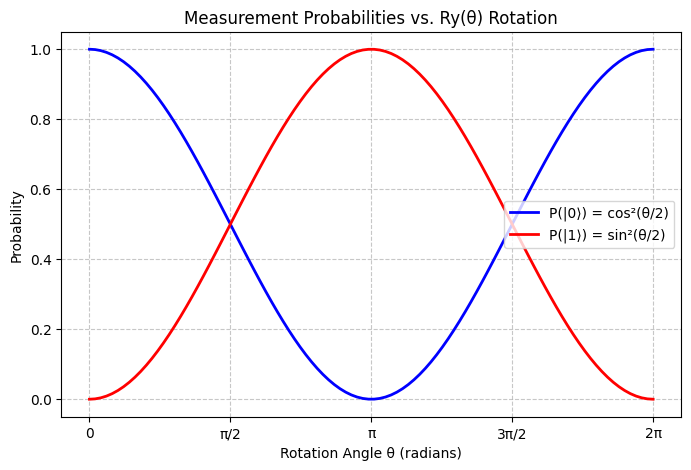

In [140]:
plt.figure(figsize=(8, 5))

plt.plot(theta, p0, label='P(|0⟩) = cos²(θ/2)', color='blue', linewidth=2)
plt.plot(theta, p1, label='P(|1⟩) = sin²(θ/2)', color='red', linewidth=2)

plt.title('Measurement Probabilities vs. Ry(θ) Rotation')
plt.xlabel('Rotation Angle θ (radians)')
plt.ylabel('Probability')

plt.xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
    ['0', 'π/2', 'π', '3π/2', '2π']
)

plt.ylim(-0.05, 1.05)

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='center right')

plt.show()

## A.11 Random rotations: measurement probabilities and the Bloch sphere

### Rotation gates

In [141]:
def Rx(theta):
    return np.array([
        [np.cos(theta / 2), -1j * np.sin(theta / 2)],
        [-1j * np.sin(theta / 2), np.cos(theta / 2)]
    ], dtype=complex)

In [142]:
def Ry(theta):
    return np.array([
        [np.cos(theta / 2), -np.sin(theta / 2)],
        [np.sin(theta / 2), np.cos(theta / 2)]
    ], dtype=complex)

In [143]:
def Rz(theta):
    return np.array([
        [np.exp(-1j * theta / 2), 0],
        [0, np.exp(1j * theta / 2)]
    ], dtype=complex)

### Verify against Pauli formulas

In [144]:
theta_test = np.pi / 3 # arbitrary angle, pi/3

print(f"Verifying Rotation Formulas for θ = {np.round(theta_test, 3)}")

rx_formula = np.cos(theta_test / 2) * I - 1j * np.sin(theta_test / 2) * X # right side of the equations: cos(θ/2)I - i*sin(θ/2)P
ry_formula = np.cos(theta_test / 2) * I - 1j * np.sin(theta_test / 2) * Y
rz_formula = np.cos(theta_test / 2) * I - 1j * np.sin(theta_test / 2) * Z

check_x = np.allclose(Rx(theta_test), rx_formula)
check_y = np.allclose(Ry(theta_test), ry_formula)
check_z = np.allclose(Rz(theta_test), rz_formula)

print(f"Rx(θ) matches formula? {check_x}")
print(f"Ry(θ) matches formula? {check_y}")
print(f"Rz(θ) matches formula? {check_z}")

Verifying Rotation Formulas for θ = 1.047
Rx(θ) matches formula? True
Ry(θ) matches formula? True
Rz(θ) matches formula? True


### Random sequence

In [145]:

theta_x, theta_y, theta_z = np.random.uniform(0, 2 * np.pi, 3) # random values

print("Random Angles (radians)")
print(f"θx: {np.round(theta_x, 4)}")
print(f"θy: {np.round(theta_y, 4)}")
print(f"θz: {np.round(theta_z, 4)}\n")

# U = Rz(θz), Ry(θy), Rx(θx)
# in linear algebra it's right to left multiplication
U = Rz(theta_z) @ Ry(theta_y) @ Rx(theta_x)

print("Overall Unitary Matrix U")
print(np.round(U, 4), "\n")

# final state |ψ⟩ ---
psi_final = U @ ket_0

print("Final State |ψ⟩")
print(np.round(psi_final, 4))

Random Angles (radians)
θx: 0.8765
θy: 1.8356
θz: 2.3019

Overall Unitary Matrix U
[[ 0.532 -0.365j  -0.5286+0.5517j]
 [ 0.5286+0.5517j  0.532 +0.365j ]] 

Final State |ψ⟩
[[0.532 -0.365j ]
 [0.5286+0.5517j]]


### Expectation values

In [146]:
paulis = {'X': X, 'Y': Y, 'Z': Z}

In [147]:
for name, M in paulis.items():
    # ⟨ψ|M|ψ⟩
    bra_psi = np.conj(psi_final).T
    exp1_matrix = bra_psi @ M @ psi_final

    exp1 = np.real(exp1_matrix[0, 0]) # apparently Hermitian operators are always real numbers so we need to drop the imaginary part (?)

    # ⟨0|U† M U|0⟩
    U_dag = np.conj(U).T
    bra_0 = np.conj(ket_0).T
    exp2_matrix = bra_0 @ U_dag @ M @ U @ ket_0

    match = np.allclose(exp1_matrix, exp2_matrix)
    
    print(f"⟨{name}⟩ = {np.round(exp1, 5)}")
    print(f"Matches ⟨0|U†{name}U|0⟩? {match}\n")

⟨X⟩ = 0.15972
Matches ⟨0|U†XU|0⟩? True

⟨Y⟩ = 0.97285
Matches ⟨0|U†YU|0⟩? True

⟨Z⟩ = -0.16747
Matches ⟨0|U†ZU|0⟩? True



### Probabilities from expectation values

In [148]:
paulis = {'X': X, 'Y': Y, 'Z': Z}

In [149]:
observables = {
    'X': (X, ket_pozitif, ket_negatif),
    'Y': (Y, ket_pozitif_i, ket_negatif_i),
    'Z': (Z, ket_0, ket_1)
}

In [150]:
for name, (M, ket_pos, ket_neg) in observables.items():
    bra_psi = np.conj(psi_final).T
    exp_val = np.real((bra_psi @ M @ psi_final)[0, 0]) # expectation value ⟨M⟩
    
    p_pos_exp = (1 + exp_val) / 2
    p_neg_exp = (1 - exp_val) / 2
    
    # direct inner product method (Born Rule) ---
    p_pos_dir = np.abs((np.conj(ket_pos).T @ psi_final)[0, 0])**2
    p_neg_dir = np.abs((np.conj(ket_neg).T @ psi_final)[0, 0])**2
    
    # verification
    match_pos = np.allclose(p_pos_exp, p_pos_dir)
    match_neg = np.allclose(p_neg_exp, p_neg_dir)
    
    print(f"Observable {name} (⟨{name}⟩ = {np.round(exp_val, 5)}):")
    print(f"  P(+1) formula: {np.round(p_pos_exp, 5)} | inner prod: {np.round(p_pos_dir, 5)} -> Match? {match_pos}")
    print(f"  P(-1) formula: {np.round(p_neg_exp, 5)} | inner prod: {np.round(p_neg_dir, 5)} -> Match? {match_neg}\n")

Observable X (⟨X⟩ = 0.15972):
  P(+1) formula: 0.57986 | inner prod: 0.57986 -> Match? True
  P(-1) formula: 0.42014 | inner prod: 0.42014 -> Match? True

Observable Y (⟨Y⟩ = 0.97285):
  P(+1) formula: 0.98643 | inner prod: 0.98643 -> Match? True
  P(-1) formula: 0.01357 | inner prod: 0.01357 -> Match? True

Observable Z (⟨Z⟩ = -0.16747):
  P(+1) formula: 0.41627 | inner prod: 0.41627 -> Match? True
  P(-1) formula: 0.58373 | inner prod: 0.58373 -> Match? True



### Bar chart of probabilities

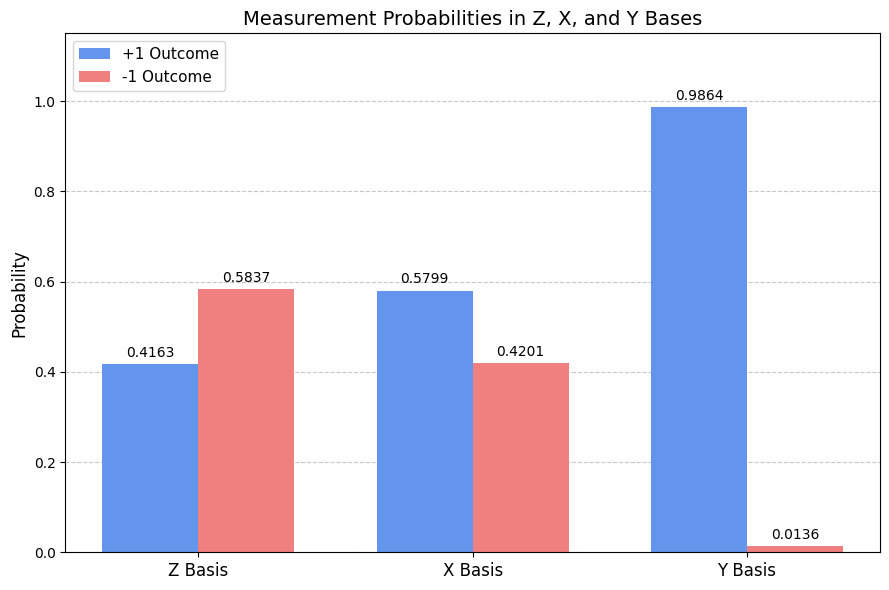

In [151]:
p_z_plus = np.abs((np.conj(ket_0).T @ psi_final)[0, 0])**2
p_z_minus = np.abs((np.conj(ket_1).T @ psi_final)[0, 0])**2

p_x_plus = np.abs((np.conj(ket_pozitif).T @ psi_final)[0, 0])**2
p_x_minus = np.abs((np.conj(ket_negatif).T @ psi_final)[0, 0])**2

p_y_plus = np.abs((np.conj(ket_pozitif_i).T @ psi_final)[0, 0])**2
p_y_minus = np.abs((np.conj(ket_negatif_i).T @ psi_final)[0, 0])**2

labels = ['Z Basis', 'X Basis', 'Y Basis']
probs_plus = [p_z_plus, p_x_plus, p_y_plus]
probs_minus = [p_z_minus, p_x_minus, p_y_minus]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

rects1 = ax.bar(x - width/2, probs_plus, width, label='+1 Outcome', color='cornflowerblue')
rects2 = ax.bar(x + width/2, probs_minus, width, label='-1 Outcome', color='lightcoral')

ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Measurement Probabilities in Z, X, and Y Bases', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)

ax.bar_label(rects1, fmt='%.4f', padding=3, fontsize=10)
ax.bar_label(rects2, fmt='%.4f', padding=3, fontsize=10)

ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

fig.tight_layout()
plt.show()

### Visualizing the state in observable space (Bloch sphere projection)

3D Bloch Vector Length Squared: 1.0 (Expected: 1.0)


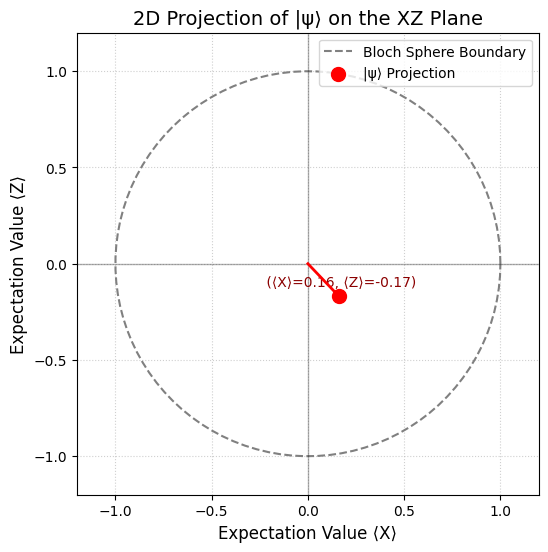

In [152]:
bra_psi = np.conj(psi_final).T
exp_X = np.real((bra_psi @ X @ psi_final)[0, 0])
exp_Y = np.real((bra_psi @ Y @ psi_final)[0, 0])
exp_Z = np.real((bra_psi @ Z @ psi_final)[0, 0])

# verify the 3D Bloch sphere constraint (X^2 + Y^2 + Z^2 = 1)
bloch_radius = exp_X**2 + exp_Y**2 + exp_Z**2
print(f"3D Bloch Vector Length Squared: {np.round(bloch_radius, 5)} (Expected: 1.0)")

fig, ax = plt.subplots(figsize=(6, 6))

theta = np.linspace(0, 2 * np.pi, 100)
circle_x = np.cos(theta)
circle_z = np.sin(theta)
ax.plot(circle_x, circle_z, linestyle='--', color='gray', label='Bloch Sphere Boundary')

ax.axhline(0, color='black', linewidth=1, alpha=0.3)
ax.axvline(0, color='black', linewidth=1, alpha=0.3)

ax.scatter(exp_X, exp_Z, color='red', s=100, zorder=5, label='|ψ⟩ Projection')

ax.plot([0, exp_X], [0, exp_Z], color='red', linewidth=2, zorder=4)

label_text = f" (⟨X⟩={exp_X:.2f}, ⟨Z⟩={exp_Z:.2f})"
ax.text(exp_X, exp_Z + 0.05, label_text, color='darkred', fontsize=10, ha='center')

ax.set_aspect('equal')
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel('Expectation Value ⟨X⟩', fontsize=12)
ax.set_ylabel('Expectation Value ⟨Z⟩', fontsize=12)
ax.set_title('2D Projection of |ψ⟩ on the XZ Plane', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, linestyle=':', alpha=0.6)

plt.show()

### Repeat for multiple random trials

Running 5 Random Trials
Trial 1: 3D Radius = 1.00000 | (X: -0.73, Y: -0.13, Z: -0.67)
Trial 2: 3D Radius = 1.00000 | (X: -0.86, Y: -0.24, Z: -0.45)
Trial 3: 3D Radius = 1.00000 | (X: 0.35, Y: 0.70, Z: 0.62)
Trial 4: 3D Radius = 1.00000 | (X: 0.15, Y: 0.95, Z: -0.26)
Trial 5: 3D Radius = 1.00000 | (X: -0.59, Y: 0.80, Z: 0.12)


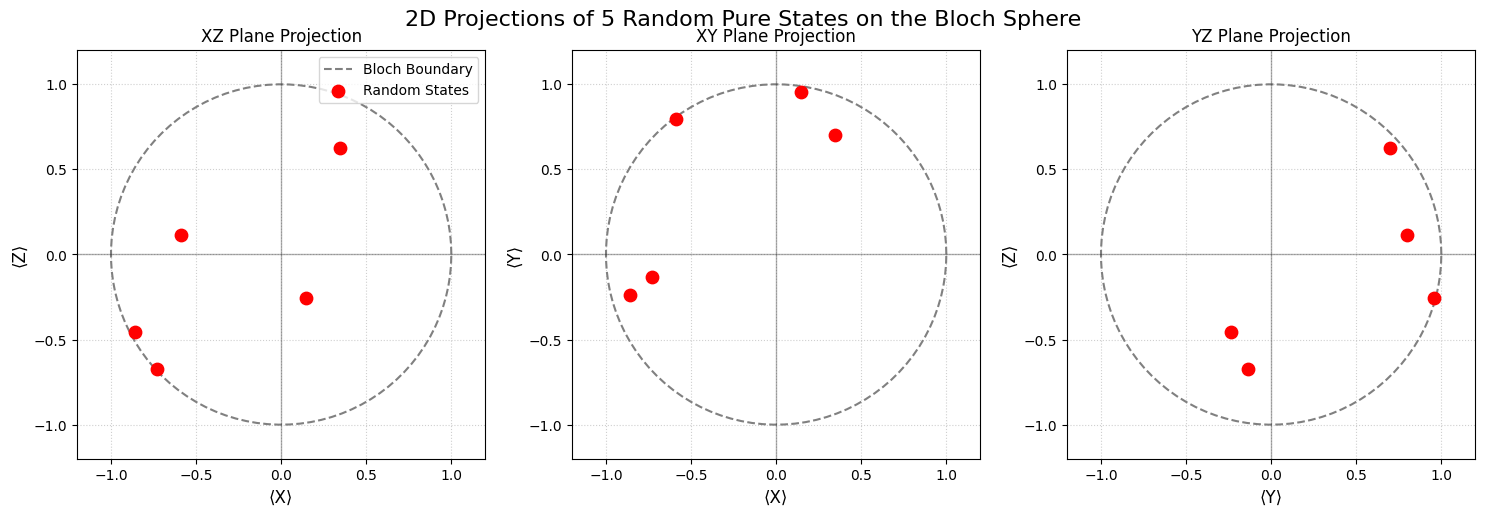

In [153]:
num_trials = 5
expectation_values = {'X': [], 'Y': [], 'Z': []}

print(f"Running {num_trials} Random Trials")

np.random.seed(42) # setting a seed so results are reproducible

for i in range(num_trials):
    tx, ty, tz = np.random.uniform(0, 2 * np.pi, 3)
    
    # unitary and final state
    U = Rz(tz) @ Ry(ty) @ Rx(tx)
    psi = U @ ket_0
    
    # expectation values
    bra_psi = np.conj(psi).T
    exp_x = np.real((bra_psi @ X @ psi)[0, 0])
    exp_y = np.real((bra_psi @ Y @ psi)[0, 0])
    exp_z = np.real((bra_psi @ Z @ psi)[0, 0])
    
    # verify 3D sphere constraint exactly equals 1
    radius_3d = np.sqrt(exp_x**2 + exp_y**2 + exp_z**2)
    print(f"Trial {i+1}: 3D Radius = {radius_3d:.5f} | (X: {exp_x:.2f}, Y: {exp_y:.2f}, Z: {exp_z:.2f})")
    
    expectation_values['X'].append(exp_x)
    expectation_values['Y'].append(exp_y)
    expectation_values['Z'].append(exp_z)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('2D Projections of 5 Random Pure States on the Bloch Sphere', fontsize=16)

# pairs of axes to plot: (X, Z), (X, Y), (Y, Z)
plot_pairs = [
    ('X', 'Z', axes[0]),
    ('X', 'Y', axes[1]),
    ('Y', 'Z', axes[2])
]

# unit circle data
theta = np.linspace(0, 2 * np.pi, 100)
circle_h = np.cos(theta)
circle_v = np.sin(theta)

for h_label, v_label, ax in plot_pairs:
    ax.plot(circle_h, circle_v, linestyle='--', color='gray', label='Bloch Boundary')
    
    ax.axhline(0, color='black', linewidth=1, alpha=0.3)
    ax.axvline(0, color='black', linewidth=1, alpha=0.3)
    
    ax.scatter(expectation_values[h_label], expectation_values[v_label], 
               color='red', s=80, zorder=5, label='Random States')
    
    ax.set_aspect('equal')
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_xlabel(f'⟨{h_label}⟩', fontsize=12)
    ax.set_ylabel(f'⟨{v_label}⟩', fontsize=12)
    ax.set_title(f'{h_label}{v_label} Plane Projection')
    ax.grid(True, linestyle=':', alpha=0.6)
    
    if h_label == 'X' and v_label == 'Z':
        ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

Why do all points lie exactly on the unit circle/sphere?  

This happens because the starting state ∣0⟩ is a pure state and rotation gates are unitary operators. Unitary operators preserve the inner product and the norm of the state vector. Therefore, no matter how many random unitary operations applied, the state vector will remain exactly 1, keeping the point strictly on the surface of the 3D Bloch sphere.

What would happen if the state were mixed?  

If a state is mixed, it means there is classical uncertainty about which pure state the qubit is actually in (for example, a 50% chance someone handed you a ∣0⟩ qubit and a 50% chance they handed you a ∣1⟩ qubit).

Expectation values are averages, a mixed state averages out the vectors of the underlying pure states. Geometrically, this pulls the coordinate point inward, meaning a mixed state is represented by a dot inside the Bloch sphere (radius <1). The completely mixed state (total maximum uncertainty) sits exactly at the origin (0,0,0) because the averages of all possible measurements cancel each other out to zero.

### Interpretation

I will be using Trial 4 data for one of the random trials,  
Trial 4: 3D Radius = 1.00000 | (X: 0.15, Y: 0.95, Z: -0.26)

### Deterministic outcome
The state had an expectation value of ⟨Y⟩=0.95. This means the Y basis gives the most "deterministic" outcome, as the probability of measuring +1 in the Y basis is very close to 100%. (specifically, P(+1)=0.975). Physically, this tells us that the quantum state ∣ψ⟩ is pointing almost exactly along the positive Y-axis of the Bloch sphere, meaning it is highly aligned with the ∣+i⟩ eigenstate.

### Eigenvalues, measurements 
The eigenvalues of the Pauli matrices (+1 and −1) represent the only physically possible outcomes when you measure a single qubit. It cannot measure a fraction. The expectation value is the statistical average of these discrete +1 and −1 outcomes over many identical trials. The mathematical result must strictly be bounded between −1 and +1. As the state coordinates never extend beyond the boundaries of the unit sphere.

### Equivalency
This equivalence comes directly from the definition of how the state is prepared. The final state is created by applying the unitary operator U to the initial zero state, so ∣ψ⟩=U∣0⟩. If we take the conjugate transpose to get the "bra" vector, the order reverses and the matrix is conjugated: ⟨ψ∣=⟨0∣U†.  
  
By directly substituting these into the expectation value formula, we get:
⟨ψ∣Z∣ψ⟩=(⟨0∣U†)Z(U∣0⟩)=⟨0∣U†ZU∣0⟩
  
This proves that rotating the state vector (Schrödinger picture) is mathematically identical to applying the inverse rotation to the measurement operator itself (Heisenberg picture).

### Why do all points lie on the unit circle
All points lie perfectly on the surface of the unit sphere (radius =1) because the system is in a pure state. The unitary operations (Rx,Ry,Rz) preserve the length of the state vector, meaning no quantum information is lost to the environment.

If we applied a non-unitary operation—like a measurement—the state would violently collapse to one of the basis states. If we then computed the expectation values over many trials without selecting for a specific measurement outcome, we would be describing a mixed state (a state with classical uncertainty). Geometrically, this averaging of collapsed states shrinks the vector length, meaning the coordinate point would fall inside the unit circle.

### Bonus challenge 

In [154]:
print("Calculating Bloch Angles")
# θ = arccos(⟨Z⟩)
theta = np.arccos(exp_Z)

# φ = arg(⟨X⟩ + i⟨Y⟩)
phi = np.angle(exp_X + 1j * exp_Y)

print(f"θ (Theta, polar angle)   = {np.round(theta, 4)} radians")
print(f"φ (Phi, azimuthal angle) = {np.round(phi, 4)} radians\n")

print("Reconstructing the State")
# |ψ⟩ = cos(θ/2)|0⟩ + e^(iφ)sin(θ/2)|1⟩
psi_recon = np.array([
    [np.cos(theta / 2)],
    [np.exp(1j * phi) * np.sin(theta / 2)]
], dtype=complex)

print("Reconstructed State from (θ, φ):")
print(np.round(psi_recon, 4), "\n")

print("Original State (from U|0⟩):")
print(np.round(psi_final, 4), "\n")

print("Verifying the Match")
# method A: check the physical overlap (Fidelity)
# if they are the same state, |⟨ψ_recon|ψ_original⟩| will equal 1.0
overlap = np.abs(np.conj(psi_recon).T @ psi_final)[0, 0]
print(f"Fidelity |⟨ψ_recon|ψ_original⟩| = {np.round(overlap, 5)} (Expected: 1.0)\n")

# method B: fix the Global Phase for an exact array match
# we extract the phase from the top element of the original state 
# and multiply our reconstructed state by it.
global_phase = np.exp(1j * np.angle(psi_final[0, 0]))
psi_recon_adjusted = psi_recon * global_phase

is_exact_match = np.allclose(psi_recon_adjusted, psi_final)
print(f"Do the arrays match exactly after adjusting for global phase? {is_exact_match}")

Calculating Bloch Angles
θ (Theta, polar angle)   = 1.7391 radians
φ (Phi, azimuthal angle) = 1.4081 radians

Reconstructing the State
Reconstructed State from (θ, φ):
[[0.6452+0.j    ]
 [0.1238+0.7539j]] 

Original State (from U|0⟩):
[[0.532 -0.365j ]
 [0.5286+0.5517j]] 

Verifying the Match
Fidelity |⟨ψ_recon|ψ_original⟩| = 1.0 (Expected: 1.0)

Do the arrays match exactly after adjusting for global phase? True


## B.1 Modify the target function

Dataset

In [155]:
# data mismatch happens if i don't add dtype
X = torch.linspace(0, torch.pi, 200, dtype=torch.float64)
y = torch.cos(2 * X)

Split it 80/20

In [156]:
torch.manual_seed(42) # for reproducibility
indices = torch.randperm(200)
train_idx, test_idx = indices[:160], indices[160:]

In [157]:
X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

Quantum Circuit

In [158]:
dev = qml.device("default.qubit", wires=1)

@qml.qnode(dev, interface="torch")
def qnode(x, params):
    qml.RY(x, wires=0)
    
    qml.RZ(params[0], wires=0)
    qml.RY(params[1], wires=0)
    qml.RX(params[2], wires=0)
    
    return qml.expval(qml.PauliZ(0))


def quantum_model(X_batch, params):
    return torch.stack([qnode(x, params) for x in X_batch])

Training

In [159]:
params = torch.rand(3, requires_grad=True, dtype=torch.float64)

# hyperparameters
learning_rate = 0.1
epochs = 150
optimizer = optim.Adam([params], lr=learning_rate)
criterion = nn.MSELoss()

train_losses = []
test_losses = []

In [160]:
print("Starting Training")
for epoch in range(epochs):
    optimizer.zero_grad()
    
    predictions = quantum_model(X_train, params)
    loss = criterion(predictions, y_train)
    
    loss.backward()
    optimizer.step()
    
    with torch.no_grad():
        test_preds = quantum_model(X_test, params)
        test_loss = criterion(test_preds, y_test)
        
    train_losses.append(loss.item())
    test_losses.append(test_loss.item())
    
    if (epoch + 1) % 30 == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {loss.item():.4f} | Test Loss: {test_loss.item():.4f}")

print("\nFinal Results")
print(f"Final Test Loss: {test_losses[-1]:.4f}")
print(f"Trained Parameters: Rz={params[0].item():.4f}, Ry={params[1].item():.4f}, Rx={params[2].item():.4f}")

Starting Training
Epoch  30 | Train Loss: 0.4177 | Test Loss: 0.4089
Epoch  60 | Train Loss: 0.4173 | Test Loss: 0.4047
Epoch  90 | Train Loss: 0.4173 | Test Loss: 0.4037
Epoch 120 | Train Loss: 0.4172 | Test Loss: 0.4043
Epoch 150 | Train Loss: 0.4172 | Test Loss: 0.4042

Final Results
Final Test Loss: 0.4042
Trained Parameters: Rz=-0.6135, Ry=1.8668, Rx=1.6996


Plotting the results

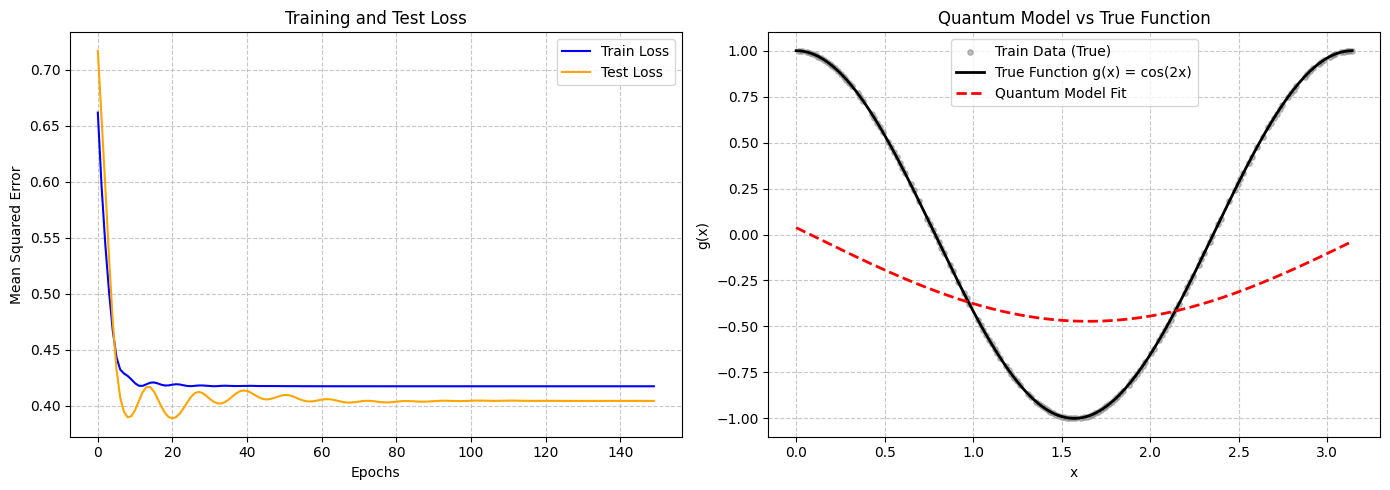

In [161]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# loss curves
ax1.plot(train_losses, label='Train Loss', color='blue')
ax1.plot(test_losses, label='Test Loss', color='orange')
ax1.set_title('Training and Test Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Mean Squared Error')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# final fit
X_sorted, sorted_indices = torch.sort(X)
y_sorted_true = torch.cos(2 * X_sorted)

with torch.no_grad():
    y_preds_sorted = quantum_model(X_sorted, params)

ax2.scatter(X_train.numpy(), y_train.numpy(), color='gray', alpha=0.5, label='Train Data (True)', s=15)
ax2.plot(X_sorted.numpy(), y_sorted_true.numpy(), color='black', label='True Function g(x) = cos(2x)', linewidth=2)
ax2.plot(X_sorted.numpy(), y_preds_sorted.numpy(), color='red', label='Quantum Model Fit', linewidth=2, linestyle='--')
ax2.set_title('Quantum Model vs True Function')
ax2.set_xlabel('x')
ax2.set_ylabel('g(x)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Does the circuit manage to learn cos(2x) well? Why or why not?

The test loss plateaus at a very high number (usually around 0.5) and the plot of the model's prediction looks like a flat wave rather than the double-dip of cos(2x) curve.  
The circuit fails to learn the function.

### Relate your answer to the theoretical form f(x)=Acosx+Bsinx. Can this form approximate cos(2x) over the interval?

It is physically impossible for the circuit to construct a wave with a frequency of 2 (like cos(2x)). No matter how we tune the trainable parameters (Rz,Ry,Rx), those gates only change the amplitude (A, B) and phase shift of a frequency-1 wave. A linear combination of cos(x) and sin(x) can never equal cos(2x), making the model fundamentally under-expressive for this specific dataset.

## B.2 Try a different circuit architecture

Dataset

In [162]:
X = torch.linspace(0, torch.pi, 200, dtype=torch.float64)
y_sin = torch.sin(X)
y_cos = torch.cos(2 * X)

Train/test split (80/20)

In [163]:
torch.manual_seed(42)
indices = torch.randperm(200)
train_idx, test_idx = indices[:160], indices[160:]

In [164]:
X_train, X_test = X[train_idx], X[test_idx]
y_train_sin, y_test_sin = y_sin[train_idx], y_sin[test_idx]
y_train_cos, y_test_cos = y_cos[train_idx], y_cos[test_idx]

Quantum circuit

In [165]:
dev = qml.device("default.qubit", wires=1)

@qml.qnode(dev, interface="torch")
def qnode_reduced(x, params):
    qml.RY(x, wires=0)
    
    qml.RZ(params[0], wires=0)
    qml.RY(params[1], wires=0)
    
    return qml.expval(qml.PauliZ(0))

def quantum_model_reduced(X_batch, params):
    return torch.stack([qnode_reduced(x, params) for x in X_batch])

Training function

In [166]:
def train_and_evaluate(X_train, y_train, X_test, y_test, title):
    print(f"Training on {title}")
    # two parameters this time
    params = torch.rand(2, requires_grad=True, dtype=torch.float64)
    optimizer = optim.Adam([params], lr=0.1)
    criterion = nn.MSELoss()
    
    train_losses, test_losses = [], []
    
    for epoch in range(150):
        optimizer.zero_grad()
        preds = quantum_model_reduced(X_train, params)
        loss = criterion(preds, y_train)
        loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            test_preds = quantum_model_reduced(X_test, params)
            test_loss = criterion(test_preds, y_test)
            
        train_losses.append(loss.item())
        test_losses.append(test_loss.item())
        
    print(f"Final Test Loss ({title}): {test_losses[-1]:.4f}\n")
    return params, train_losses, test_losses

# train on both datasets
params_sin, train_loss_sin, test_loss_sin = train_and_evaluate(X_train, y_train_sin, X_test, y_test_sin, "f(x) = sin(x)")
params_cos, train_loss_cos, test_loss_cos = train_and_evaluate(X_train, y_train_cos, X_test, y_test_cos, "g(x) = cos(2x)")

Training on f(x) = sin(x)
Final Test Loss (f(x) = sin(x)): 0.0000

Training on g(x) = cos(2x)
Final Test Loss (g(x) = cos(2x)): 0.4042



Plotting the results

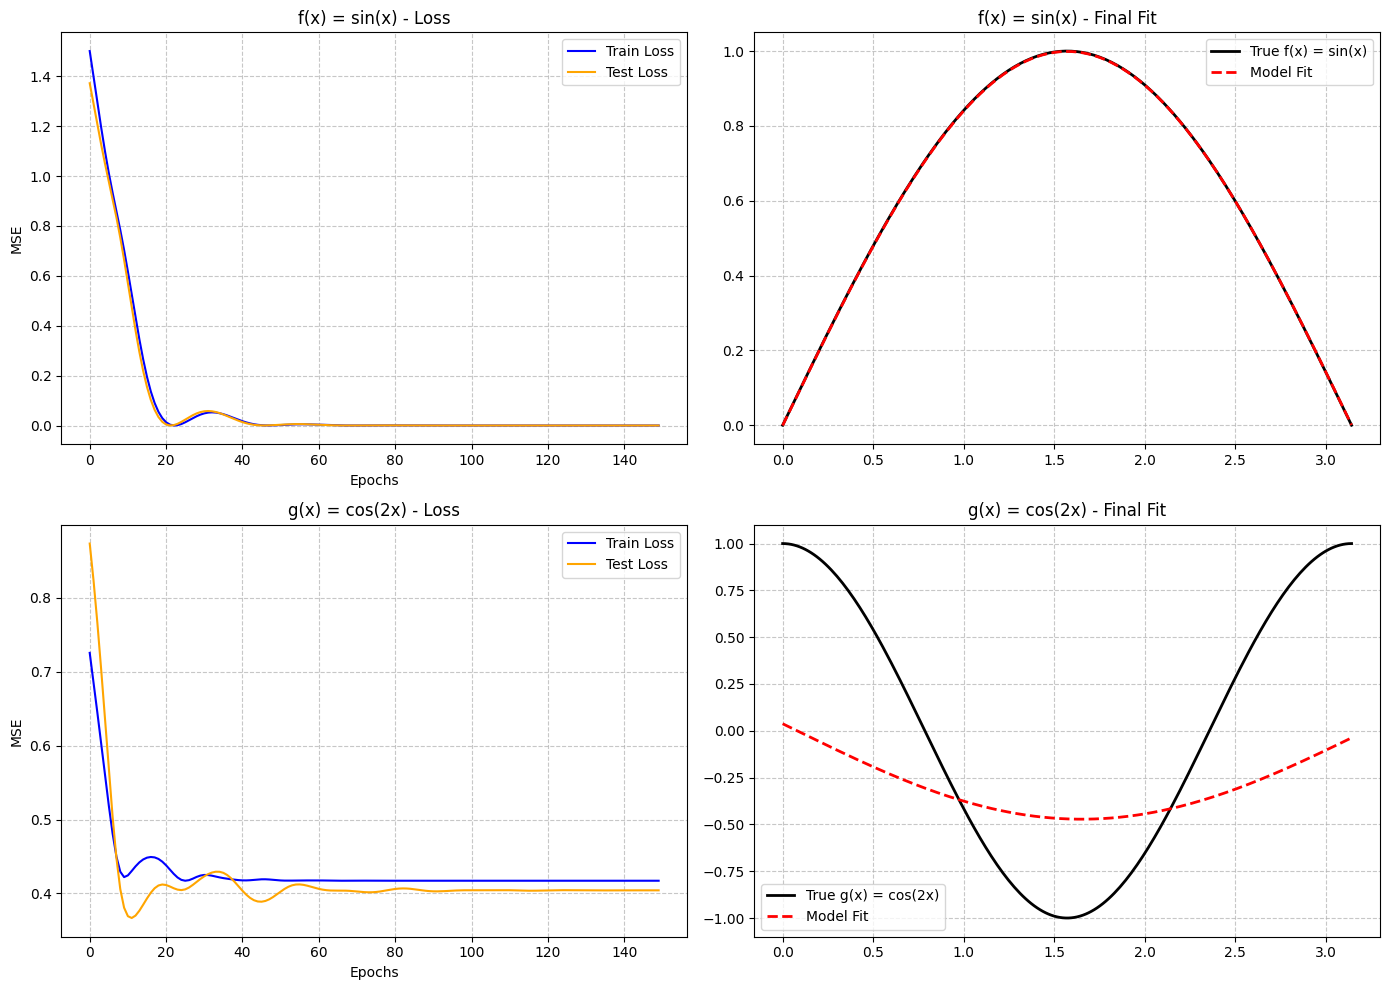

In [167]:
# explicitly unpack the 2x2 grid into four separate axis variables
# i don't know why but it didn't work first time i tried it
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
X_sorted, _ = torch.sort(X)

def plot_results(ax_loss, ax_fit, train_loss, test_loss, params, target_name, y_true_sorted):
    # loss plot
    ax_loss.plot(train_loss, label='Train Loss', color='blue')
    ax_loss.plot(test_loss, label='Test Loss', color='orange')
    ax_loss.set_title(f'{target_name} - Loss')
    ax_loss.set_xlabel('Epochs')
    ax_loss.set_ylabel('MSE')
    ax_loss.legend()
    ax_loss.grid(True, linestyle='--', alpha=0.7)
    
    # fit plot
    with torch.no_grad():
        y_preds = quantum_model_reduced(X_sorted, params)
    ax_fit.plot(X_sorted.numpy(), y_true_sorted.numpy(), color='black', label=f'True {target_name}', linewidth=2)
    ax_fit.plot(X_sorted.numpy(), y_preds.numpy(), color='red', label='Model Fit', linestyle='--', linewidth=2)
    ax_fit.set_title(f'{target_name} - Final Fit')
    ax_fit.legend()
    ax_fit.grid(True, linestyle='--', alpha=0.7)

plot_results(ax1, ax2, train_loss_sin, test_loss_sin, params_sin, "f(x) = sin(x)", torch.sin(X_sorted))
plot_results(ax3, ax4, train_loss_cos, test_loss_cos, params_cos, "g(x) = cos(2x)", torch.cos(2*X_sorted))

plt.tight_layout()
plt.show()

### Comparison and some explanation

For f(x)=sin(x): The loss drops to zero, and the model perfectly overlaps the target curve.  
For g(x)=cos(2x): The model fails completely, giving you the exact same flat, high-loss line as it did in B.1.

### What functions can this reduced circuit represent?

By removing the Rx gate, we haven't changed the fundamental frequency the circuit can output, we have only slightly restricted its amplitude coefficients. We can prove this by calculating the expectation value ⟨Z⟩ mathematically (working backwards from the measurement).

When the encoded state ∣ψx⟩=Ry(x)∣0⟩ is passed through Rz(θ1) and Ry(θ2), the final expectation value resolves to:
f(x)=cos(θ2)cos(x)+sin(θ2)cos(θ1)sin(x)

This matches the general form Acos(x)+Bsin(x), just with specific constraints on the coefficients:

A=cos(θ2)

B=sin(θ2)cos(θ1)

### Why does it succeed on sin(x) but fail on cos(2x)?

To output a pure sin(x) wave, the circuit just needs A=0 and B=1. It can easily achieve this if the optimizer sets θ2≈π/2 and θ1≈0. Because the required frequency is 1, the reduced circuit has enough expressive power to fit the data perfectly.

This reduced circuit is strictly limited to combinations of cos(x) and sin(x). It is mathematically impossible to construct a wave with a frequency of 2 using only components with a frequency of 1.

## B.3 Learn a step function

Dataset

In [168]:
X = torch.linspace(-torch.pi, torch.pi, 200, dtype=torch.float64)

Step function

In [169]:
y = torch.where(X < 0, torch.tensor(-1.0, dtype=torch.float64), torch.tensor(1.0, dtype=torch.float64))

Train/test split (80/20)

In [170]:
torch.manual_seed(42)
indices = torch.randperm(200)
train_idx, test_idx = indices[:160], indices[160:]

In [171]:
X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

Quantum circuit

In [172]:
dev = qml.device("default.qubit", wires=1)

@qml.qnode(dev, interface="torch")
def qnode(x, params):
    qml.RY(x, wires=0)
    qml.RZ(params[0], wires=0)
    qml.RY(params[1], wires=0)
    qml.RX(params[2], wires=0)
    return qml.expval(qml.PauliZ(0))

def quantum_model(X_batch, params):
    return torch.stack([qnode(x, params) for x in X_batch])

Training

In [173]:
params = torch.rand(3, requires_grad=True, dtype=torch.float64)
optimizer = optim.Adam([params], lr=0.1)
criterion = nn.MSELoss()

print("Training on Step Function")
train_losses, test_losses = [], []

for epoch in range(150):
    optimizer.zero_grad()
    preds = quantum_model(X_train, params)
    loss = criterion(preds, y_train)
    loss.backward()
    optimizer.step()
    
    with torch.no_grad():
        test_preds = quantum_model(X_test, params)
        test_loss = criterion(test_preds, y_test)
        
    train_losses.append(loss.item())
    test_losses.append(test_loss.item())
    
    if (epoch + 1) % 30 == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {loss.item():.4f} | Test Loss: {test_loss.item():.4f}")

Training on Step Function
Epoch  30 | Train Loss: 0.2601 | Test Loss: 0.1662
Epoch  60 | Train Loss: 0.2499 | Test Loss: 0.1588
Epoch  90 | Train Loss: 0.2486 | Test Loss: 0.1589
Epoch 120 | Train Loss: 0.2486 | Test Loss: 0.1590
Epoch 150 | Train Loss: 0.2486 | Test Loss: 0.1591


Plotting the results

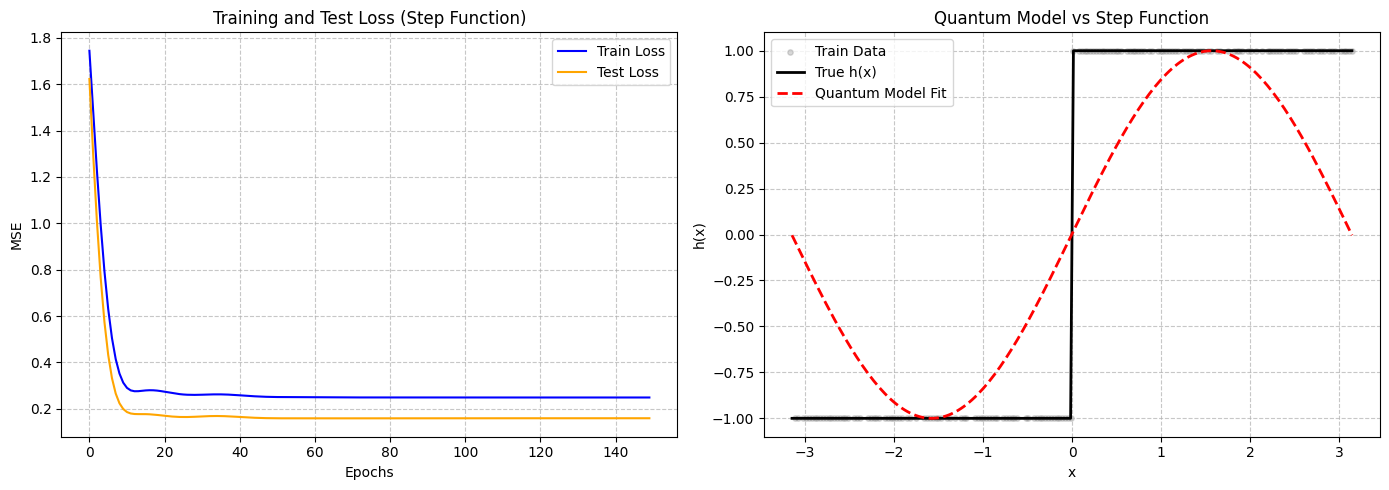

In [174]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

X_sorted, sorted_indices = torch.sort(X)
y_sorted_true = torch.where(X_sorted < 0, torch.tensor(-1.0), torch.tensor(1.0))

# loss plot
ax1.plot(train_losses, label='Train Loss', color='blue')
ax1.plot(test_losses, label='Test Loss', color='orange')
ax1.set_title('Training and Test Loss (Step Function)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('MSE')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# fit plot
with torch.no_grad():
    y_preds_sorted = quantum_model(X_sorted, params)

ax2.scatter(X_train.numpy(), y_train.numpy(), color='gray', alpha=0.3, label='Train Data', s=15)
ax2.plot(X_sorted.numpy(), y_sorted_true.numpy(), color='black', label='True h(x)', linewidth=2)
ax2.plot(X_sorted.numpy(), y_preds_sorted.numpy(), color='red', label='Quantum Model Fit', linewidth=2, linestyle='--')
ax2.set_title('Quantum Model vs Step Function')
ax2.set_xlabel('x')
ax2.set_ylabel('h(x)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Instead of a sharp rectangular step, the model traces out a rolling S shape, like a sin(x) function

### Can it fit a sharp step? Why?

No, the circuit absolutely cannot fit a sharp step function. It approximates the step with a smooth, single-frequency sine wave.

This happens due to the spectral limitations of the quantum circuit. As established earlier, a single-qubit circuit with a single Ry(x) encoding gate can only express functions of the form f(x)=Acos(x)+Bsin(x)+C.

## B.4 Written summary

I have learned about the single-qubit circuit with a data encoding gate that is linked to simple trigonometric functions. General form of any function it can represent is restricted to a Fourier series of f(x)=Acos(x)+Bsin(x)+C. Though adding more trainable rotations like chaining Rx, Ry, and Rz gates allow the circuit to tinker with Bloch sphere to find the amplitude and phase shift, it doesn't increase the frequency of the output. Also, this architecture is incapable of capturing higher-frequency patterns like cos(2x) or sharp step function. When designing quantum machine learning models understanding the limitations is important.

I have used Gemini 3.1 Pro and Deepseek-V3.2 while writing this assignment for topic explanations, understanding the required questions, mathematical proofs, notations, on error handling (an example would be a data mismatch between torch and pylance), on elevating the explanations markdowns to a formal level rather than a casual one and so on.   